## A study of "Smart" and "Ultra" tariff plans for a mobile operator

    Clients are offered two pricing plans: "Smart" and "Ultra".
    To adjust the advertising budget, the commercial department wants to understand 
    which plan brings in more revenue. They need to analyze client behavior and determine which plan is better.

**Plan Description**

***Smart Plan***

    Monthly fee: 550 rubles
    Includes 500 minutes of talk time, 50 messages, and 15 GB of data
    Cost of services above the plan:

    Call minute: 3 rubles
    Message: 3 rubles
    1 GB of data: 200 rubles

***Ultra Plan***

    Monthly fee: 1950 rubles
    Includes 3000 minutes of talk time, 1000 messages, and 30 GB of data
    Cost of services above the plan:

    Call minute: 1 ruble
    Message: 1 ruble
    1 GB of data: 150 rubles

    Company always rounds up the amount of minutes and megabytes. 
    If the user spoke for only 1 second, the tariff counts as a whole minute.

## Contents:
* [Step 1. General Information](#1-bullet)
* [Step 2. Data Preprocessing](#2-bullet)
* 2.1. [Converting Data to the Required Types](#2-1-bullet)
* 2.2. [Working with Gaps](#2-2-bullet)
* 2.3. [Number of Calls and Minutes Spent by Month](#2-3-bullet)
* 2.4. [Number of Sent Messages by Month](#2-4-bullet)
* 2.5. [Internet Traffic Consumed by Month](#2-5-bullet)
* 2.6. [Share of Smart and Ultra Plan Subscribers in the Sample](#2-6-bullet)
* 2.7. [Monthly Revenue Per User](#2-7-bullet)
* [Step 3. Data Analysis](#3-bullet)
* 3.1. [How Many Talk Minutes Does a User of Each Plan Need Per Month](#3-1-bullet)
* 3.2. [How Many Messages Does a User of Each Plan Need Per Month](#3-2-bullet)
* 3.3. [What Amount of Internet Traffic Does a User of Each Plan Need Per Month](#3-3-bullet)
* [Step 4. Hypothesis Testing](#4-bullet)
* 4.1. [The Average Revenue of Users of the "Ultra" and "Smart" Plans Differs](#4-1-bullet)
* 4.2. [The Average Revenue of Users in Moscow Differs from That of Users in Other Regions](#4-2-bullet)
* [Step 5. General Conclusion](#5-bullet)

### Step 1. General Information<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
users = pd.read_csv('https://code.s3.yandex.net/datasets/users.csv')
users.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


**Data Description**:
***Users Table (User Information)***

* user_id — unique user ID
* first_name — user's first name
* last_name — user's last name
* age — user's age (years)
* reg_date — plan activation date (day, month, year)
* churn_date — plan termination date (if omitted, the plan was still active at the time of data download)
* city — user's city of residence
* tariff — plan name

In [3]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [4]:
 users['user_id'].duplicated().sum()

0

In [5]:
users['city'].unique()

array(['Краснодар', 'Москва', 'Стерлитамак', 'Новокузнецк',
       'Набережные Челны', 'Ульяновск', 'Челябинск', 'Пермь', 'Тюмень',
       'Самара', 'Санкт-Петербург', 'Иваново', 'Чебоксары', 'Омск', 'Уфа',
       'Томск', 'Чита', 'Мурманск', 'Петрозаводск', 'Тверь',
       'Екатеринбург', 'Махачкала', 'Вологда', 'Череповец', 'Ярославль',
       'Сочи', 'Хабаровск', 'Ставрополь', 'Рязань', 'Улан-Удэ', 'Тула',
       'Саратов', 'Ростов-на-Дону', 'Казань', 'Иркутск', 'Курск',
       'Калуга', 'Якутск', 'Астрахань', 'Химки', 'Владикавказ',
       'Волгоград', 'Саранск', 'Ижевск', 'Новосибирск', 'Брянск',
       'Тольятти', 'Нижний Тагил', 'Орёл', 'Белгород', 'Воронеж',
       'Волжский', 'Курган', 'Барнаул', 'Красноярск', 'Архангельск',
       'Липецк', 'Кемерово', 'Киров', 'Сургут', 'Пенза', 'Магнитогорск',
       'Нижний Новгород', 'Кострома', 'Владивосток', 'Тамбов', 'Балашиха',
       'Севастополь', 'Калининград', 'Оренбург', 'Смоленск',
       'Нижневартовск', 'Владимир', 'Новороссий

* The 'users' table has 8 columns and 500 rows.
* The ['churn_date'] column contains missing values. If a value is missing, the tariff was still in effect at the time the data was downloaded. Therefore, 462 tariffs were in effect at the time the data was downloaded, and 38 were not. The missing values ​​will be left in place, as the data in this column is not needed for the purposes of this study.
- In the ['churn_date'] and ['reg_date'] columns, the values ​​must be converted from strings to dates.
- In the ['user_id'] column, all users are unique, there are no duplicates.
- Since later in the study, the sample will need to be grouped by region ("Moscow" and "other regions"), I made sure that the ['city'] column does not contain different spellings of the city "Moscow."

In [6]:
calls = pd.read_csv('https://code.s3.yandex.net/datasets/calls.csv')
calls.head(5)

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


**Data Description**: ***Calls Table (Call Information)***

* id — unique call number
* call_date — call date
* duration — call duration in minutes
* user_id — user ID of the user who made the call

In [7]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB


* The 'calls' table has 4 columns and 202 607 rows
* There are no missing values ​​in the columns
* The ['call_date'] column requires converting the values ​​from a string to a date.

In [8]:
messages = pd.read_csv('https://code.s3.yandex.net/datasets/messages.csv')
messages.head(5)

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


**Data Description**: ***Messages Table (message information)***

* id — unique message number
* message_date — message date
* user_id — user ID of the user who sent the message

In [9]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            123036 non-null  object
 1   message_date  123036 non-null  object
 2   user_id       123036 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.8+ MB


* The 'messages' table has 3 columns and 123 036 rows
* There are no missing values ​​in the columns
* The ['message_date'] column requires conversion from string to date.

In [10]:
internet = pd.read_csv('https://code.s3.yandex.net/datasets/internet.csv')
internet.head(5)

,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


**Data Description**: ***Internet Table (Internet Session Information)***

* id — unique session number
* mb_used — internet traffic used during the session (in megabytes)
* session_date — internet session date
* user_id — user ID

In [11]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  object 
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  object 
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB


* The 'internet' table has 4 columns and 149 396 rows
* There are no missing values ​​in the columns
* The ['session_date'] column must be converted from a string to a date.

In [12]:
tariffs = pd.read_csv('https://code.s3.yandex.net/datasets/tariffs.csv')
tariffs.head(5)

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


**Data Description**: ***Tariffs Table (Tariff Information)***

* tariff_name — tariff name
* rub_monthly_fee — monthly subscription fee in rubles
* minutes_included — number of minutes of talk time per month included in the subscription fee
* messages_included — number of messages per month included in the subscription fee
* mb_per_month_included — internet traffic volume included in the subscription fee (in megabytes)
* rub_per_minute — cost per minute of talk time over and above the tariff plan (e.g., if the plan includes 100 minutes of talk time per month, the fee will be charged starting from the 101st minute)
* rub_per_message — cost of sending a message over and above the tariff plan
* rub_per_gb — cost of an additional gigabyte of internet traffic over and above the tariff plan (1 gigabyte = 1024 megabytes)

In [13]:
tariffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 256.0+ bytes


* The 'tariffs' table has 8 columns and 2 rows
* There are no missing values ​​in the columns
* The table does not contain any columns that need to be converted to a different data type

## Step 2. Data Preprocessing<a class="anchor" id="2-bullet"></a>

### 2.1. Converting Data to the Required Types<a class="anchor" id="2-1-bullet"></a>

#### Users Table

In [14]:
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

In [15]:
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')

In [16]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   age         500 non-null    int64         
 2   churn_date  38 non-null     datetime64[ns]
 3   city        500 non-null    object        
 4   first_name  500 non-null    object        
 5   last_name   500 non-null    object        
 6   reg_date    500 non-null    datetime64[ns]
 7   tariff      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


  
    In the columns ['churn_date'] and ['reg_date'] the values ​​have been converted from string to date.

#### Calls Table

In [17]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

In [18]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         202607 non-null  object        
 1   call_date  202607 non-null  datetime64[ns]
 2   duration   202607 non-null  float64       
 3   user_id    202607 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.2+ MB


    In the ['call_date'] column, the values ​​have been converted from string to date.

####  Messages Table

In [19]:
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')

In [20]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            123036 non-null  object        
 1   message_date  123036 non-null  datetime64[ns]
 2   user_id       123036 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB



    The ['message_date'] column has had its values ​​converted from string to date.

####  Internet Table

In [21]:
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')

In [22]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    149396 non-null  int64         
 1   id            149396 non-null  object        
 2   mb_used       149396 non-null  float64       
 3   session_date  149396 non-null  datetime64[ns]
 4   user_id       149396 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 5.7+ MB



    The ['session_date'] column has been converted from string to date. 

### 2.2. Working with Gaps<a class="anchor" id="2-2-bullet"></a>

Let's look at the data in the calls table in the ['duration'] column.

In [23]:
calls['duration'].describe()

count    202607.000000
mean          6.755887
std           5.843365
min           0.000000
25%           1.300000
50%           6.000000
75%          10.700000
max          38.000000
Name: duration, dtype: float64

Text(0.5, 0, 'Call Duration in Minutes')

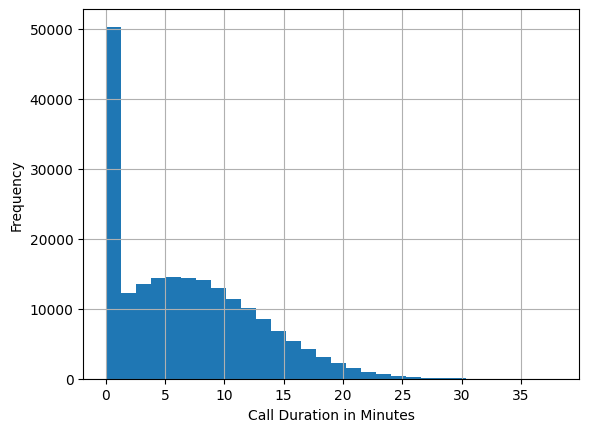

In [24]:
calls['duration'].plot(kind='hist', grid=True, bins=30)
plt.xlabel("Call Duration in Minutes")


    The data includes calls with a duration of 0 minutes.
    Let's determine the exact number of such calls in the sample.

In [25]:
len(calls[(calls['duration']==0)]) / len(calls)

0.19551644316336553

In [26]:
min_duration = calls[(calls['duration']==0)]
len(min_duration)

39613


    Thus, the sample contains 39 613 calls with a duration of 0 minutes.
    Calls with zero duration account for 19.5% of the total number of calls.

    The data looks suspicious, as mobile operators always round up
    minutes and megabytes. If a user only spoke for 1 second, the tariff
    should count a full minute.

    Let's check which tariff these calls are assigned to. 
    To do this, we'll combine the two tables:
    calls and users.

In [27]:
calls_tariffs = calls.merge(users, on='user_id', how='left')
calls_tariffs.head()

,id,call_date,duration,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000_0,2018-07-25,0.00,1000,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1000_1,2018-08-17,0.00,1000,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
2,1000_2,2018-06-11,2.85,1000,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
3,1000_3,2018-09-21,13.80,1000,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
4,1000_4,2018-12-15,5.18,1000,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra


In [28]:
calls_tariffs.query('duration == 0.00').pivot_table(index='tariff', values='duration', aggfunc='count')

,duration
tariff,
smart,25669
ultra,13944


    
    Calls with a duration of 0 minutes are present in both plans:
    the Smart plan has 25,669 calls, while the Ultra plan has 13,944.

    Therefore, it's impossible to assume that either plan 
    experienced a rounding error causing zero values.

    It's possible that the dataset includes outgoing calls that weren't answered 
    for some reason: dropped, the other party was unavailable, or the call was rejected. 
    In other words, there was an outgoing call, but the call duration was 0 minutes. \
    Such calls don't deduct minutes from the package and don't generate revenue for the operator; 
    there's no point in considering them for the purposes of this study. 
    For this reason, I'll delete all calls with a duration of 0 minutes.

In [29]:
calls['duration'] = calls['duration'].replace(0, np.NaN)
calls = calls.dropna()

In [30]:
calls['duration'].describe()

count    162994.000000
mean          8.397794
std           5.353022
min           0.010000
25%           4.170000
50%           7.740000
75%          11.850000
max          38.000000
Name: duration, dtype: float64


    We see that the minimum value has changed from 0 to 0.01.
    Since tariff prices are determined per minute of call, and the mobile operator always 
    rounds up to the nearest whole minute, we round the values ​​using np.ceil.

In [31]:
calls['duration'] = calls['duration'].apply(np.ceil)

In [32]:
calls['duration'].describe()

count    162994.000000
mean          8.897880
std           5.353761
min           1.000000
25%           5.000000
50%           8.000000
75%          12.000000
max          38.000000
Name: duration, dtype: float64

Text(0.5, 0, 'Call Duration in Minutes')

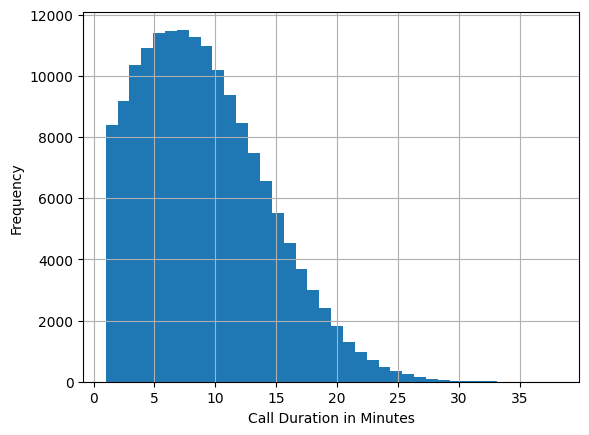

In [33]:
calls['duration'].plot(kind='hist', grid=True, bins=38)
plt.xlabel("Call Duration in Minutes")

    
    The ['duration'] column no longer displays calls with a duration of 0 minutes.
    The minimum call duration is 1 minute. All call durations are rounded to the nearest minute.

    Let's look at the internet table and the values ​​in the ['mb_used'] column.

In [34]:
internet['mb_used'].describe()

count    149396.000000
mean        370.192426
std         278.300951
min           0.000000
25%         138.187500
50%         348.015000
75%         559.552500
max        1724.830000
Name: mb_used, dtype: float64

Text(0.5, 0, 'Internet Traffic Volume, MB')

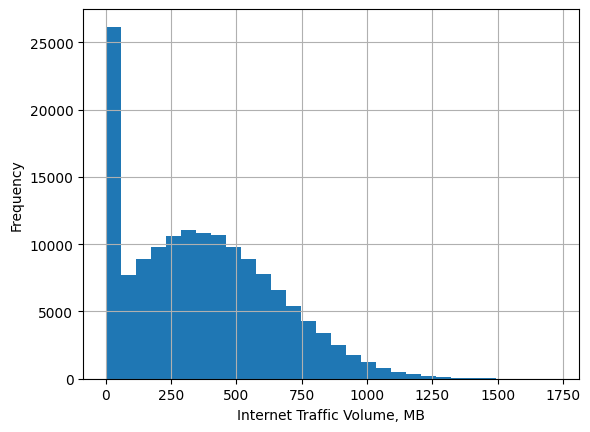

In [35]:
internet['mb_used'].plot(kind='hist', grid=True, bins=30)
plt.xlabel("Internet Traffic Volume, MB")

   
    The data includes sessions with 0 megabytes of internet traffic used.
    Let's determine the exact number of such sessions in the sample.

In [36]:
len(internet[(internet['mb_used']==0)]) / len(internet)*100

13.118155773916303

In [37]:
min_mb_used = internet[(internet['mb_used']==0)]
len(min_mb_used)

19598

    Thus, 0 megabytes were used during 19 598 sessions.
    Sessions with 0 megabytes of traffic consumed account for 13.1% of the total number of sessions.
    The data appears suspicious, as mobile operators always round up
    values ​​to the nearest whole megabyte.

    The international organization Ookla studied four major Russian mobile operators:
    MTS, Beeline, Megafon, and Tele2. According to data for the first half of 2019:
    - Average download speed from 7.93 MB per second to 11.88 MB per second
    - Average download speed from 14.51 MB per second to 27.31 MB per second

    Let's assume the session lasted less than a second and no operation was performed.
    For example, the website didn't load, there was a connection error, a crash, etc. 
    Therefore, no megabytes were used and are not deducted from the subscriber's package. 
    Sessions with 0 megabytes of traffic are not needed for the assigned tasks and will be deleted.

In [38]:
internet['mb_used'] = internet['mb_used'].replace(0, np.NaN)
internet = internet.dropna()

In [39]:
internet['mb_used'].describe()

count    129798.000000
mean        426.087210
std         255.596447
min           0.030000
25%         227.460000
50%         400.540000
75%         592.947500
max        1724.830000
Name: mb_used, dtype: float64

     The minimum value has changed from 0 to 0.03 MB.
    Since the rates in the plans are determined per MB, we round the values ​​using np.ceil

In [40]:
internet['mb_used'] = internet['mb_used'].apply(np.ceil)

In [41]:
internet['mb_used'].describe()

count    129798.000000
mean        426.581758
std         255.596114
min           1.000000
25%         228.000000
50%         401.000000
75%         593.000000
max        1725.000000
Name: mb_used, dtype: float64

Text(0.5, 0, 'Internet Traffic Volume, MB')

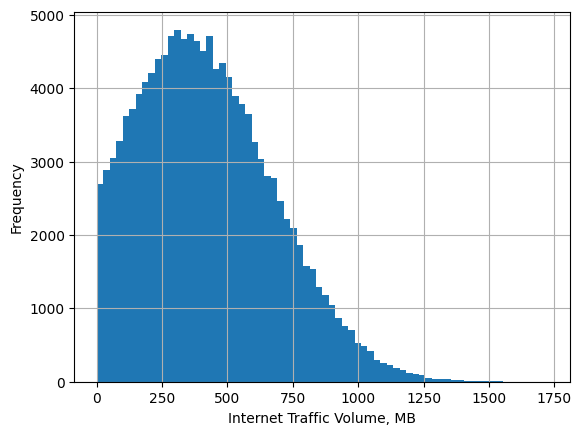

In [42]:
internet['mb_used'].plot(kind='hist', grid=True, bins=70)
plt.xlabel("Internet Traffic Volume, MB")

    The ['mb_used'] column no longer displays sessions with 0 megabytes of traffic used.
    The minimum value has changed from "0" to "1" MB.
    All traffic used has been rounded up to the nearest MB.

### 2.3. Number of Calls and Minutes Spent by Month<a class="anchor" id="2-3-bullet"></a>

  
    Let's add a new column ['month'] to the calls table

In [43]:
calls['month'] = calls['call_date'].dt.month

In [44]:
calls.head()

,id,call_date,duration,user_id,month
2,1000_2,2018-06-11,3.0,1000,6
3,1000_3,2018-09-21,14.0,1000,9
4,1000_4,2018-12-15,6.0,1000,12
7,1000_7,2018-08-22,19.0,1000,8
8,1000_8,2018-09-15,19.0,1000,9


In [45]:
calls_by_month = calls.groupby('month').agg({'id':'nunique', 'duration':'sum'}).reset_index()
calls_by_month.columns = ['month', 'qty_calls', 'duration_per_month']
calls_by_month

,month,qty_calls,duration_per_month
0,1,1164,10784.0
1,2,2705,24455.0
2,3,5383,48151.0
3,4,7504,66310.0
4,5,10116,88810.0
5,6,11833,105180.0
6,7,14780,131746.0
7,8,17257,153698.0
8,9,19446,173475.0
9,10,21757,193928.0


Text(0.5, 1.0, 'Number of Calls and Minutes Spent by Month')

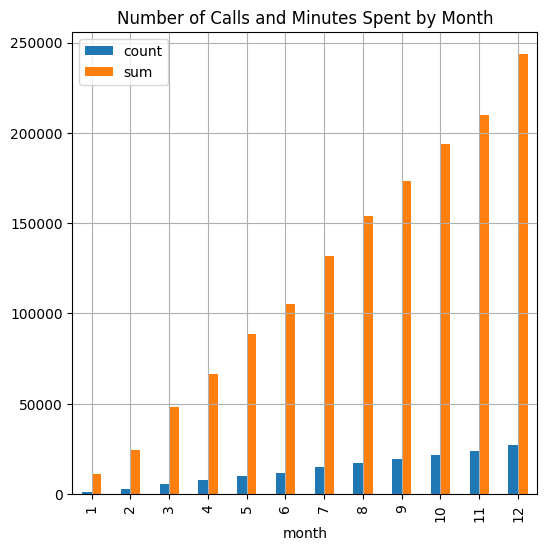

In [46]:
calls.pivot_table(index='month', values='duration', aggfunc=('count','sum')).plot(kind='bar', grid=True, figsize=(6, 6))
plt.title('Number of Calls and Minutes Spent by Month')

    1. We see a correlation: the more calls made per month, the more minutes consumed per month.

    2. The number of calls and minutes consumed increases from January to December.
    There is an increase each month. This could happen, for example, 
    if the plans were launched in January, and the number of subscribers increased each month.

### 2.4. Number of Sent Messages by Month<a class="anchor" id="2-4-bullet"></a>

In [47]:
messages['month'] = messages['message_date'].dt.month

In [48]:
messages.head()

,id,message_date,user_id,month
0,1000_0,2018-06-27,1000,6
1,1000_1,2018-10-08,1000,10
2,1000_2,2018-08-04,1000,8
3,1000_3,2018-06-16,1000,6
4,1000_4,2018-12-05,1000,12


In [49]:
messages.pivot_table(index='month', values='id', aggfunc='count')

,id
month,
1,924
2,1924
3,3648
4,5179
5,7298
6,8983
7,11320
8,13088
9,14759


Text(0.5, 1.0, 'Number of Sent Messages by Month')

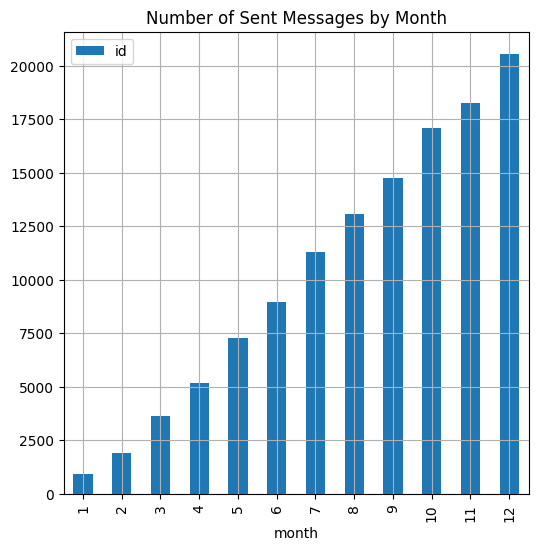

In [50]:
messages.pivot_table(index='month', values='id', aggfunc='count').plot(kind='bar', grid=True, figsize=(6, 6))
plt.title('Number of Sent Messages by Month')

    The number of messages sent increased each month from January to December.
    Each month sees an increase. The graph looks similar to the previous graph 
    (number of calls and minutes used).

### 2.5. Internet Traffic Consumed by Month<a class="anchor" id="2-5-bullet"></a>

In [51]:
internet['month'] = internet['session_date'].dt.month

In [52]:
internet.head()

,Unnamed: 0,id,mb_used,session_date,user_id,month
0,0,1000_0,113.0,2018-11-25,1000,11
1,1,1000_1,1053.0,2018-09-07,1000,9
2,2,1000_2,1198.0,2018-06-25,1000,6
3,3,1000_3,551.0,2018-08-22,1000,8
4,4,1000_4,303.0,2018-09-24,1000,9


In [53]:
internet_by_month = internet.groupby('month').agg({'id':'nunique', 'mb_used':'sum'}).reset_index()
internet_by_month.columns = ['month', 'qty_session', 'mb_used_per_month']
internet_by_month

,month,qty_session,mb_used_per_month
0,1,966,408213.0
1,2,2263,956348.0
2,3,4262,1813960.0
3,4,5692,2436111.0
4,5,8209,3529893.0
5,6,9656,4184770.0
6,7,11788,5035299.0
7,8,14009,6005126.0
8,9,15198,6454931.0
9,10,17367,7400754.0


Text(0.5, 1.0, 'Internet Traffic Consumed by Month')

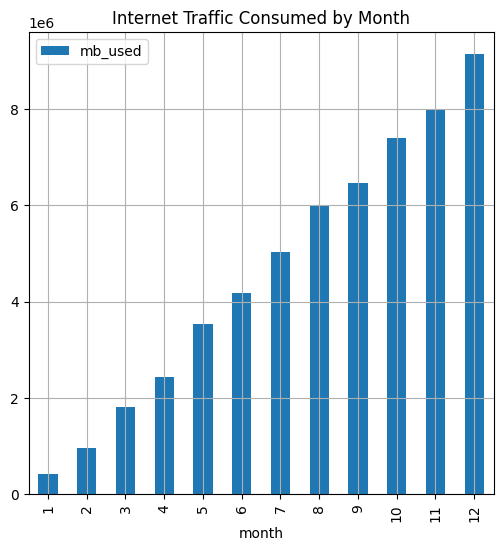

In [54]:
internet.pivot_table(index='month', values='mb_used', aggfunc='sum').plot(kind='bar', grid=True, figsize=(6, 6))
plt.title('Internet Traffic Consumed by Month')

    Internet traffic usage increased each month from January to December.
    Each month sees an increase. The graph looks similar to the previous two 
    (number of calls and messages).

###  2.6 Share of Smart and Ultra Plan Subscribers in the Sample<a class="anchor" id="2-6-bullet"></a>

    To calculate, we need to combine data from several tables.

In [55]:
inf_from_calls = calls.groupby(['user_id', 'month'])['duration'].sum()

In [56]:
inf_from_messages = messages.groupby(['user_id', 'month'])['id'].count()

In [57]:
inf_from_internet = internet.groupby(['user_id', 'month'])['mb_used'].sum()

In [58]:
common_table = pd.concat([inf_from_calls, inf_from_messages, inf_from_internet], axis=1)
common_table = common_table.reset_index()
common_table.columns = ['user_id', 'month', 'call_duration', 'amount_message', 
                            'internet_mb_used']
common_table.head()

,user_id,month,call_duration,amount_message,internet_mb_used
0,1000,5,159.0,22.0,2256.0
1,1000,6,172.0,60.0,23257.0
2,1000,7,340.0,75.0,14016.0
3,1000,8,408.0,81.0,14070.0
4,1000,9,466.0,57.0,14581.0


Let's add user data from the users table to the table.

In [59]:
common_table = common_table.merge(users, on='user_id', how='left')
common_table.head()

,user_id,month,call_duration,amount_message,internet_mb_used,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,5,159.0,22.0,2256.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1000,6,172.0,60.0,23257.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
2,1000,7,340.0,75.0,14016.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
3,1000,8,408.0,81.0,14070.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
4,1000,9,466.0,57.0,14581.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra


    Since the plans are charged per gigabyte, let's convert megabytes to gigabytes.
    Next, we'll round the values ​​up to the nearest whole number.

In [60]:
common_table['internet_gb_used'] = common_table['internet_mb_used'] / 1024 

In [61]:
common_table['internet_gb_used'] = common_table['internet_gb_used'].apply(np.ceil)

In [62]:
common_table['internet_gb_used'].describe()

count    3201.000000
mean       17.400187
std         7.343968
min         1.000000
25%        13.000000
50%        17.000000
75%        21.000000
max        49.000000
Name: internet_gb_used, dtype: float64

    Let's check subscription preferences based on plan.
    First, let's find out how many subscribers have chosen the SMART plan 
    and how many have chosen the ULTRA plan.

In [63]:
common_table['tariff'].value_counts()

smart    2229
ultra     985
Name: tariff, dtype: int64

Text(0.5, 1.0, 'Share of Smart and Ultra Plan Subscribers')

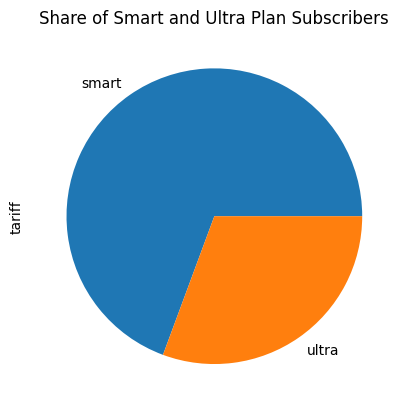

In [64]:
common_table['tariff'].value_counts().plot(y='tariff', kind='pie')
plt.title('Share of Smart and Ultra Plan Subscribers')

    Subscribers with the SMART plan make up 69.35% of the total sample.
    Subscribers with the ULTRA plan make up 30.65% of the total sample.

    Let's look at the metrics for subscribers of the two plans:
    call duration, number of messages, and data plan volume.

In [65]:
tariff_table = common_table.groupby('tariff').agg({'amount_message':'sum', 'call_duration':['count','sum'], 'internet_gb_used':['count','sum']}).reset_index()
tariff_table

tariff amount_message call_duration           internet_gb_used         
                    sum         count       sum            count      sum
0  smart        74413.0          2221  931577.0             2227  36465.0
1  ultra        48623.0           947  518724.0              974  19233.0

    Since there are more subscribers on the SMART plan, their share of calls, messages, 
    and internet traffic is also higher. Let's plot graphs for each of these indicators.

Text(0.5, 1.0, 'Number of Messages Sent')

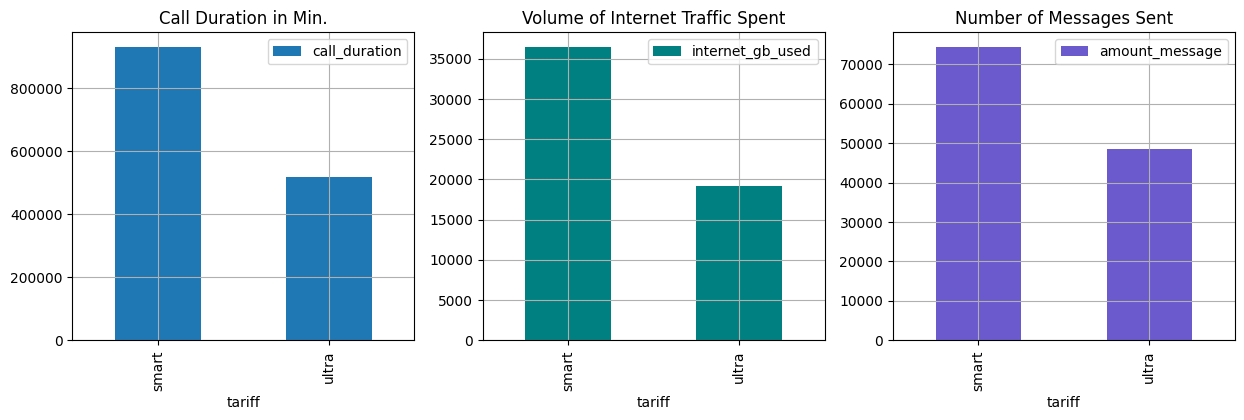

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
common_table.pivot_table(index='tariff', values='call_duration', aggfunc='sum').plot(kind='bar', grid=True, ax=axes[0])
common_table.pivot_table(index='tariff', values='internet_gb_used', aggfunc='sum').plot(kind='bar', grid=True, ax=axes[1], color='teal')
common_table.pivot_table(index='tariff', values='amount_message', aggfunc='sum').plot(kind='bar', grid=True, ax=axes[2], color='slateblue')
axes[0].set_title('Call Duration in Min.')
axes[1].set_title('Volume of Internet Traffic Spent')
axes[2].set_title('Number of Messages Sent')

    The fact that there are more SMART subscribers than ULTRA subscribers, 
    and they are more active, does not mean that the SMART plan is more profitable for the mobile operator. 
    It is necessary to check the monthly revenue per user.

###  2.7. Monthly Revenue Per User<a class="anchor" id="2-7-bullet"></a>

    Let's create a new column in which we subtract the free minute limit from the total number of calls per month.

In [67]:
def calls_over_tariff(row):
    if row['tariff'] == 'smart':
        result = row['call_duration'] - 500
        return np.where(result > 0, result, 0)
    else:
        result = row['call_duration'] - 3000
        return np.where(result > 0, result, 0)

In [68]:
common_table['extra_minutes'] = common_table.apply(calls_over_tariff, axis=1)

    Let's create a new column in which we subtract the free message limit from the total number of messages for the month.

In [69]:
def message_over_tariff(row):
    if row['tariff'] == 'smart':
        result = row['amount_message'] - 50
        return np.where(result > 0, result, 0)
    else:
        result =  row['amount_message'] - 1000
        return np.where(result > 0, result, 0)

In [70]:
common_table['extra_message'] = common_table.apply(message_over_tariff, axis=1)

    Let's create a new column in which we subtract the free internet traffic limit from the monthly traffic used.

In [71]:
def internet_over_tariff(row):
    if row['tariff'] == 'smart':
        result = row['internet_gb_used'] - 15
        return np.where(result > 0, result, 0)
    else:
        result = row['internet_gb_used'] - 30 
        return np.where(result > 0, result, 0)

In [72]:
common_table['extra_internet'] = common_table.apply(internet_over_tariff, axis=1)

In [73]:
common_table.head() 

,user_id,month,call_duration,amount_message,internet_mb_used,age,churn_date,city,first_name,last_name,reg_date,tariff,internet_gb_used,extra_minutes,extra_message,extra_internet
0,1000,5,159.0,22.0,2256.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,3.0,0.0,0.0,0.0
1,1000,6,172.0,60.0,23257.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,23.0,0.0,0.0,0.0
2,1000,7,340.0,75.0,14016.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,14.0,0.0,0.0,0.0
3,1000,8,408.0,81.0,14070.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,14.0,0.0,0.0,0.0
4,1000,9,466.0,57.0,14581.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,15.0,0.0,0.0,0.0


Let's multiply the resulting remainder by the values ​​from the tariff plan:

In [74]:
def income_calls(row):
    if row['tariff'] == 'smart':
        result = row['extra_minutes'] * 3
        return result
    else:
        result = row['extra_minutes'] * 1
        return result

In [75]:
common_table['income_calls'] = common_table.apply(income_calls, axis=1)

In [76]:
def income_message(row):
    if row['tariff'] == 'smart':
        result = row['extra_message'] * 3
        return result
    else:
        result = row['extra_message'] * 1
        return result

In [77]:
common_table['income_message'] = common_table.apply(income_message, axis=1)

In [78]:
def income_internet(row):
    if row['tariff'] == 'smart':
        result = row['extra_internet'] * 200
        return result
    else:
        result = row['extra_internet'] * 150
        return result

In [79]:
common_table['income_internet'] = common_table.apply(income_internet, axis=1)

    Let's look at how much subscribers of the two plans exceeded their basic package limits.
    What they had to pay extra for and how much.

In [80]:
common_table.pivot_table(index='tariff', values=('income_calls', 'income_message', 'income_internet'), aggfunc='sum')

,income_calls,income_internet,income_message
tariff,,,
smart,278217.0,1342800.0,38784.0
ultra,0.0,119250.0,0.0


    From the table above, we see that SMART subscribers exceed their limit in all categories: calls, messages, and data traffic.
    For each category, subscribers incur additional charges in addition to their monthly fee.
    The largest overpayments are for data traffic – 1 342 000 rubles,
    followed by calls – 278 000 rubles,
    and lastly, for messages – 38 000 rubles.

    Subscribers on the ULTRA plan exceed their limit only for data traffic.
    They pay an additional charge only for additional data traffic. The total is 119 000 rubles, which is
    only 8.88% of the total overpayments for data traffic for SMART subscribers.

    Let's sum up all additional costs in one column ['total_income'].

In [81]:
common_table['total_income'] = common_table['income_calls'] + common_table['income_message'] + common_table['income_internet']    

    We will add the subscription fee to the resulting figure:

In [82]:
def revenue(row):
    if row['tariff'] == 'smart':
        result = row['total_income'] + 550
        return result
    else:
        result = row['total_income'] + 1950
        return result

In [83]:
common_table['revenue'] = common_table.apply(revenue, axis=1)

In [84]:
common_table.pivot_table(index='tariff', values='revenue', aggfunc=('sum', 'mean', 'median'))

,mean,median,sum
tariff,,,
smart,1294.63930,1038.0,2885751.0
ultra,2071.06599,1950.0,2040000.0


    Comparing only the total revenue by plan is incorrect.
    We know that there are almost twice as many subscribers on the SMART plan as on the ULTRA plan.
    Accordingly, the total revenue will be higher. It's necessary to compare the average revenue generated by one user of one and the other plan.

    As we see above:
    - Average revenue per user of the SMART plan is 1 295 rubles (median: 1 038 rubles)
    - Average revenue per user of the ULTRA plan is 2 071 rubles (median: 1 950 rubles)

    The ULTRA plan generates more revenue than the SMART plan. The operator needs to adjust its advertising budget in favor of the ULTRA plan. This statement will be verified further in the analysis.

    Let's add a "subscription fee" column to analyze revenue for each plan:
    Which brings in more income: the monthly fee for a service package or the additional fee for
    "extra" services?

In [85]:
def rub_monthly_fee_groups(row):
    if row['tariff'] == 'smart':
        return '550'
    else:
        return '1950'
 
common_table['rub_monthly_fee'] = common_table.apply(rub_monthly_fee_groups, axis=1)
pd.set_option('display.max_columns', None)
common_table.head()

,user_id,month,call_duration,amount_message,internet_mb_used,age,churn_date,city,first_name,last_name,reg_date,tariff,internet_gb_used,extra_minutes,extra_message,extra_internet,income_calls,income_message,income_internet,total_income,revenue,rub_monthly_fee
0,1000,5,159.0,22.0,2256.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950
1,1000,6,172.0,60.0,23257.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950
2,1000,7,340.0,75.0,14016.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950
3,1000,8,408.0,81.0,14070.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950
4,1000,9,466.0,57.0,14581.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950


In [86]:
common_table['rub_monthly_fee'] = pd.to_numeric(common_table['rub_monthly_fee'], errors='coerce')
common_table['rub_monthly_fee'] = round(common_table['rub_monthly_fee'])

In [87]:
common_table['rub_monthly_fee'].describe()

count    3214.000000
mean      979.060361
std       645.539596
min       550.000000
25%       550.000000
50%       550.000000
75%      1950.000000
max      1950.000000
Name: rub_monthly_fee, dtype: float64

    Let's compare the ratio of subscription fees to additional services for each tariff.

In [88]:
common_table.pivot_table(index='tariff', values=('rub_monthly_fee', 'total_income'), aggfunc='sum')

,rub_monthly_fee,total_income
tariff,,
smart,1225950,1659801.0
ultra,1920750,119250.0


<AxesSubplot:xlabel='tariff'>

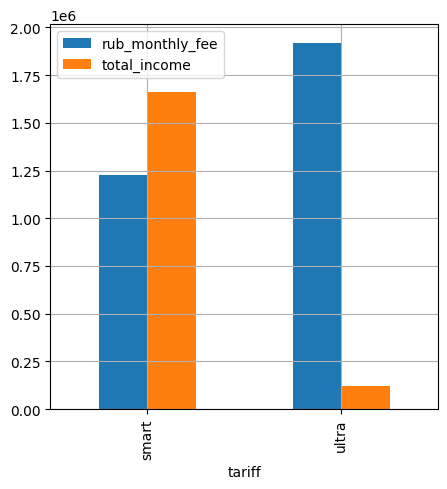

In [89]:
common_table.pivot_table(index='tariff', values=('rub_monthly_fee', 'total_income'), aggfunc='sum').plot(kind='bar', grid=True, figsize=(5, 5))

    In the SMART plan, the majority of revenue comes from surcharges for "extra" services,
    when subscribers exceed their package limit.
    These surcharges account for 57.5% of total revenue for the plan.
    The monthly fee accounts for 42.5%.
    Below, we'll look at the ratio of surcharges for "extra" services in three categories:
    calls, messages, and internet data, relative to the monthly fee.

    In the ULTRA plan, the monthly fee accounts for the majority of revenue at 94.2%.
    Surcharges for "extra" services account for only 5.8%.
    As previously determined, subscribers to this plan never exceeded their call or message limits during the year. 
    All surcharges were for additional internet traffic.

In [90]:
common_table.query('tariff == "smart"').pivot_table(index='tariff', values=('income_calls', 'income_message', 'income_internet', 'rub_monthly_fee'), aggfunc='sum')

,income_calls,income_internet,income_message,rub_monthly_fee
tariff,,,,
smart,278217.0,1342800.0,38784.0,1225950


Text(0.5, 1.0, 'SMART Plan Income by Category:\nSubscription Fee, Calls, Internet, Messages')

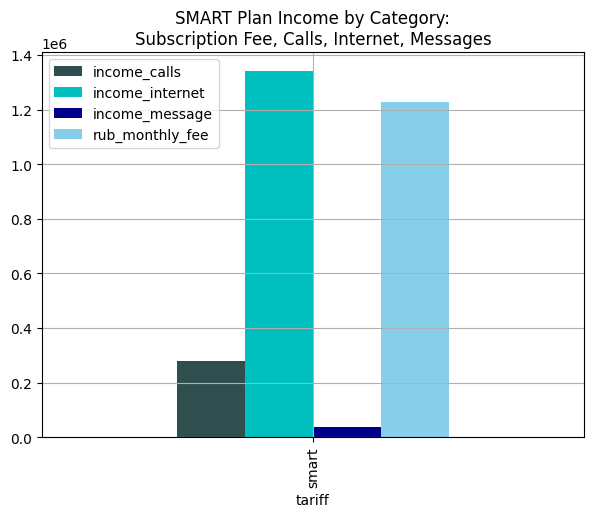

In [91]:
common_table.query('tariff == "smart"').pivot_table(index='tariff', values=('income_internet', 'rub_monthly_fee', 'income_calls', 'income_message'), aggfunc='sum').plot(kind='bar', grid=True, color = ('darkslategrey', 'c', 'darkblue', 'skyblue'), figsize=(7, 5))
plt.title('SMART Plan Income by Category:\nSubscription Fee, Calls, Internet, Messages')

    SMART plan subscribers primarily pay extra for additional data usage.
    This amount exceeds the monthly fee by 9.5%.

    The revenue for the SMART plan is as follows:
    - Internet surcharge = 46.5%
    - Monthly fee = 42.5%
    - Call minutes surcharge = 9.6%
    - Message surcharge = 1.4%

## Step 3. Data Analysis<a class="anchor" id="3-bullet"></a>

### 3.1. How Many Talk Minutes Does a User of Each Plan Need Per Month<a class="anchor" id="3-1-bullet"></a>

    Let's plot boxplots for both plans to compare the medians and interquartile ranges.

(-10.0, 1450.0)

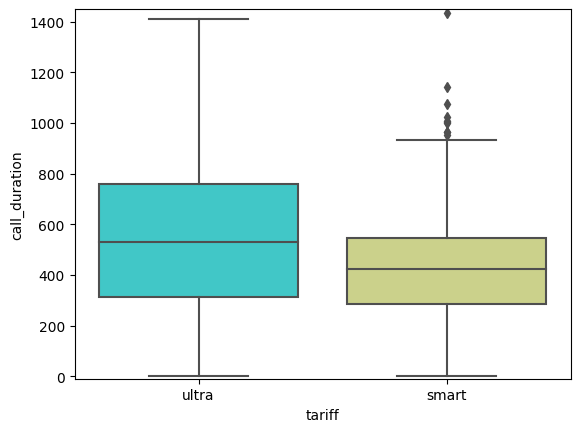

In [92]:
import seaborn as sns
sns.boxplot(x="tariff", y="call_duration", data=common_table, palette='rainbow')
plt.ylim(-10, 1450)

    We see that the median and interquartile range for the ULTRA plan are larger than those for the SMART plan.
    This means that subscribers with the ULTRA plan, on average, use more call minutes than subscribers with the SMART plan. 
    We also see that the ULTRA plan's dataset is more skewed to the right (the right whisker is longer). 
    This channel attracts subscribers who spend more call minutes than the median.

    We'll plot separate range charts for the plans to more accurately identify outliers and remove them for further data analysis.

(-10.0, 940.0)

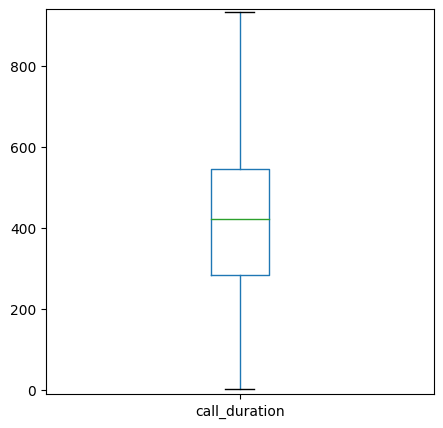

In [93]:
common_table.query('tariff == "smart"')['call_duration'].plot.box(figsize=(5,5))
plt.ylim(-10, 940)

(-10.0, 1415.0)

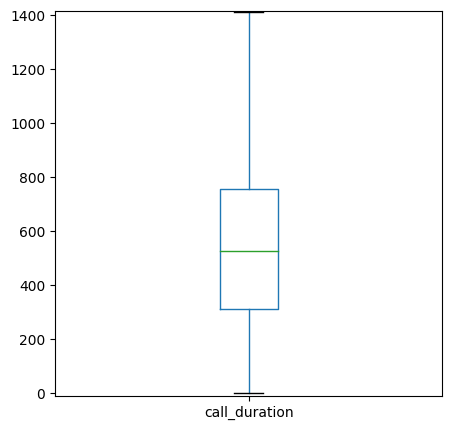

In [94]:
common_table.query('tariff == "ultra"')['call_duration'].plot.box(figsize=(5,5))
plt.ylim(-10, 1415)

    Let's create tables for each tariff without outliers.
    We'll calculate the mean, median, variance, and standard deviation.

In [95]:
smart_call_duration = common_table[(common_table['tariff'] == 'smart') & (common_table['call_duration'] < 940)]
ultra_call_duration = common_table[(common_table['tariff'] == 'ultra') & (common_table['call_duration'] < 1415)]

In [96]:
mean_calls_ultra = ultra_call_duration['call_duration'].mean()
mean_calls_smart = smart_call_duration['call_duration'].mean()
median_calls_ultra = ultra_call_duration['call_duration'].median()
median_calls_smart = smart_call_duration['call_duration'].median()
dispersion_ultra_calls = ultra_call_duration['call_duration'].var()
dispersion_smart_calls = smart_call_duration['call_duration'].var()
std_ultra_calls = ultra_call_duration['call_duration'].std()
std_smart_calls = smart_call_duration['call_duration'].std()
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average call duration per month, Ultra Plan {:.0f}'.format(mean_calls_ultra), 'min')
print('Average call duration per month, Smart Plan {:.0f}'.format(mean_calls_smart), 'min')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Median call duration per month, Ultra Plan {:.0f}'.format(median_calls_ultra), 'min')
print('Медиана длительности разговоров в месяц, Smart Plan {:.0f}'.format(median_calls_smart), 'min')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Dispersion - conversations per month, Ultra Plan: {:.0f}'.format(dispersion_ultra_calls))
print('Dispersion - conversations per month, Smart Plan: {:.0f}'.format(dispersion_smart_calls))
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Standard deviation - calls per month, Ultra Plan: {:.0f}'.format(std_ultra_calls))
print('Standard deviation - calls per month, Smart Plan: {:.0f}'.format(std_smart_calls))

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average call duration per month, Ultra Plan 545 min
Average call duration per month, Smart Plan 417 min
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Median call duration per month, Ultra Plan 528 min
Медиана длительности разговоров в месяц, Smart Plan 421 min
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Dispersion - conversations per month, Ultra Plan: 90996
Dispersion - conversations per month, Smart Plan: 33947
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Standard deviation - calls per month, Ultra Plan: 302
Standard deviation - calls per month, Smart Plan: 184


    Let's simultaneously plot a histogram and a density distribution graph for both tariffs.

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Minutes of conversation, ULTRA')

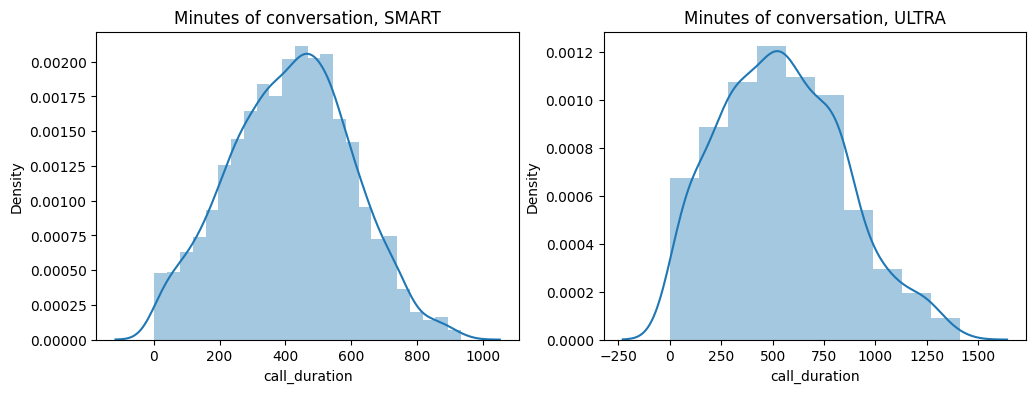

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.distplot(smart_call_duration['call_duration'], ax=axes[0])
sns.distplot(ultra_call_duration['call_duration'], bins=10, ax=axes[1])
axes[0].set_title('Minutes of conversation, SMART')
axes[1].set_title('Minutes of conversation, ULTRA')

 
**Conclusion:**

    1) Subscribers with the SMART plan use an average of 417 minutes of talk time per month.
    The plan includes 500 minutes of talk time.

    2) Subscribers with the ULTRA plan use an average of 545 minutes of talk time per month.
    The plan includes 3,000 minutes of talk time, i.e., almost five times more than the average subscriber needs.
    Therefore, subscribers overpay for call minutes and don't use them, which
    benefits the operator. As we found above, not a single subscriber exceeded their limit in this category.

  
    Let's see how many SMART subscribers have missed their 500-minute call limit at least once.

In [98]:
smart_call_duration.query('extra_minutes > 0')['user_id'].count()

744

    744 subscribers exceeded the 500-minute call limit at least once, representing 33.4% of all SMART plan users.
    Let's look at the behavior of subscribers who exceeded their limit, month by month.

In [99]:
smart_call_duration.query('extra_minutes > 0').pivot_table(index='month', values='user_id', aggfunc='count')

,user_id
month,
1,1
2,11
3,23
4,28
5,40
6,50
7,69
8,76
9,95


Text(0.5, 1.0, 'Number of Subscribers Exceeded Minutes Limit,\n SMART Plan')

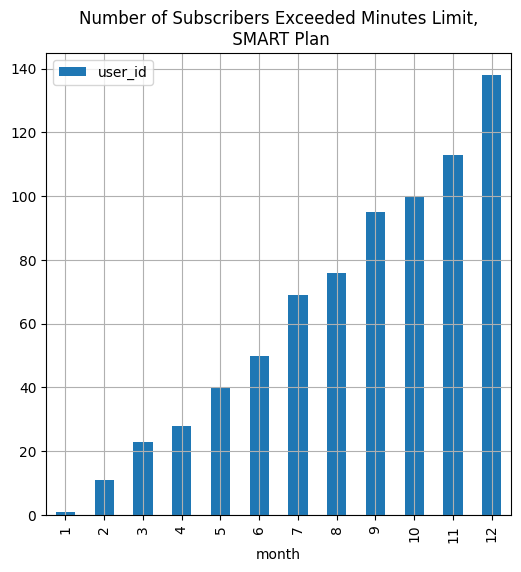

In [100]:
smart_call_duration.query('extra_minutes > 0').pivot_table(index='month', values='user_id', aggfunc='count').plot(kind='bar', grid=True, figsize=(6, 6))
plt.title('Number of Subscribers Exceeded Minutes Limit,\n SMART Plan')

    The number of SMART subscribers exceeding their limit increased each month from January to December. While only one subscriber exceeded their limit in January, the maximum number in December was 138.

    This represents only 6.2% of the total number of subscribers. Thus, in December, the month with the highest call minute usage, 93.8% of subscribers exceeded their 500-minute limit.

### 3.2. How Many Messages Does a User of Each Plan Need Per Month<a class="anchor" id="3-2-bullet"></a>

    Let's plot boxplots for both tariffs to compare the medians and interquartile ranges.

(-10.0, 200.0)

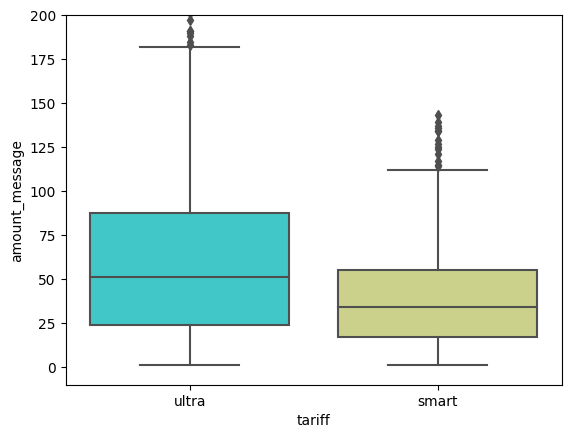

In [101]:
sns.boxplot(x="tariff", y="amount_message", data=common_table, palette='rainbow')
plt.ylim(-10, 200)

    We see that the median and interquartile range for the ULTRA plan are larger than those for the SMART plan. This means that subscribers with the ULTRA plan, on average, send more messages than subscribers with the SMART plan. We also see that the ULTRA plan's dataset is more strongly skewed to the right (the right whisker is longer). This channel attracts those who send messages more than the median.

    We'll plot separate range charts for the plans to more accurately identify outliers and remove them in further data analysis.

(0.0, 115.0)

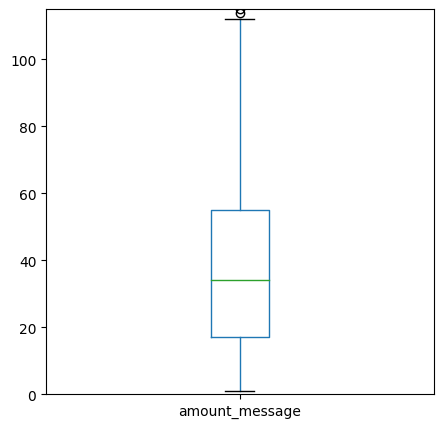

In [102]:
common_table.query('tariff == "smart"')['amount_message'].plot.box(figsize=(5,5))
plt.ylim(0, 115)

(0.0, 184.0)

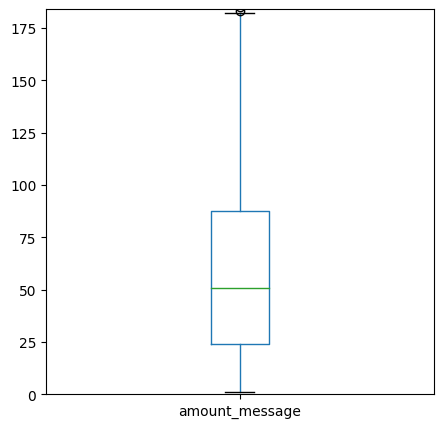

In [103]:
common_table.query('tariff == "ultra"')['amount_message'].plot.box(figsize=(5,5))
plt.ylim(0, 184)

In [104]:
smart_message = common_table[(common_table['tariff'] == 'smart') & (common_table['amount_message'] < 113)]
ultra_message = common_table[(common_table['tariff'] == 'ultra') & (common_table['amount_message'] < 183)]

In [105]:
mean_ultra_message = ultra_message['amount_message'].mean()
mean_smart_message = smart_message['amount_message'].mean()
median_ultra_message = ultra_message['amount_message'].median()
median_smart_message = smart_message['amount_message'].median()
dispersion_ultra_message = ultra_message['amount_message'].var()
dispersion_smart_calls = smart_message['amount_message'].var()
std_ultra_message = ultra_message['amount_message'].std()
std_smart_message = smart_message['amount_message'].std()
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average number of messages per month, Ultra plan {:.0f}'.format(mean_ultra_message), 'шт.')
print('Average number of messages per month, Smart plan {:.0f}'.format(mean_smart_message), 'шт.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Median number of messages per month, Ultra plan {:.0f}'.format(median_ultra_message), 'шт.')
print('Median number of messages per month, Smart plan {:.0f}'.format(median_smart_message), 'шт.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Dispersion - number of messages, Ultra plan: {:.0f}'.format(dispersion_ultra_message))
print('Dispersion - number of messages, Smart plan: {:.0f}'.format(dispersion_smart_calls))
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Standard deviation - number of messages, Ultra plan: {:.0f}'.format(std_ultra_message))
print('Standard deviation - number of messages, Smart plan: {:.0f}'.format(std_smart_message))
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average number of messages per month, Ultra plan 59 шт.
Average number of messages per month, Smart plan 38 шт.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Median number of messages per month, Ultra plan 50 шт.
Median number of messages per month, Smart plan 33 шт.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Dispersion - number of messages, Ultra plan: 1868
Dispersion - number of messages, Smart plan: 663
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Standard deviation - number of messages, Ultra plan: 43
Standard deviation - number of messages, Smart plan: 26
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


    Let's plot histograms and a density distribution graph for both tariffs.

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Messages Amount, ULTRA')

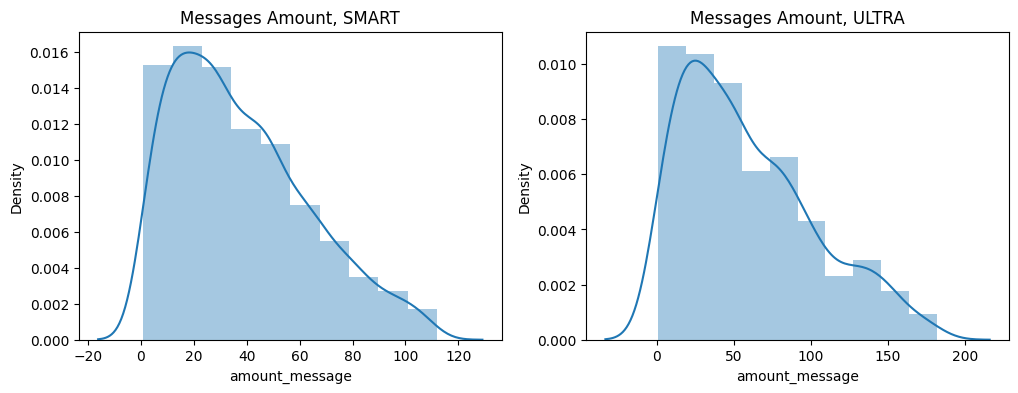

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.distplot(smart_message['amount_message'], bins=10, ax=axes[0])
sns.distplot(ultra_message['amount_message'], bins=10, ax=axes[1])
axes[0].set_title('Messages Amount, SMART')
axes[1].set_title('Messages Amount, ULTRA')

**Conclusion:**

    1) Subscribers on the SMART plan send an average of 38 messages per month.
    The plan includes 50 messages per month.

    2) Subscribers on the ULTRA plan send an average of 59 messages per month.
    The plan includes 1 000 messages, i.e., almost 17 times more than the average subscriber needs.
    Therefore, subscribers overpay for messages and don't use them, which benefits the operator.
    As we found above, not a single subscriber exceeded their limit in this category.

      Let's see how many SMART subscribers have missed their 500-minute call limit at least once.

In [107]:
smart_message.query('extra_message > 0')['user_id'].count()

550

    550 subscribers exceeded the 50-message limit at least once per month, representing 24.7% of all SMART plan users. Let's look at the behavior of subscribers who exceeded their limit by month.

In [108]:
smart_message.query('extra_message > 0').pivot_table(index='month', values='user_id', aggfunc='count')

,user_id
month,
1,1
2,6
3,19
4,22
5,35
6,42
7,52
8,60
9,63


Text(0.5, 1.0, 'Number of Subscribers Exceeded Messages Limit,\nSMART Plan')

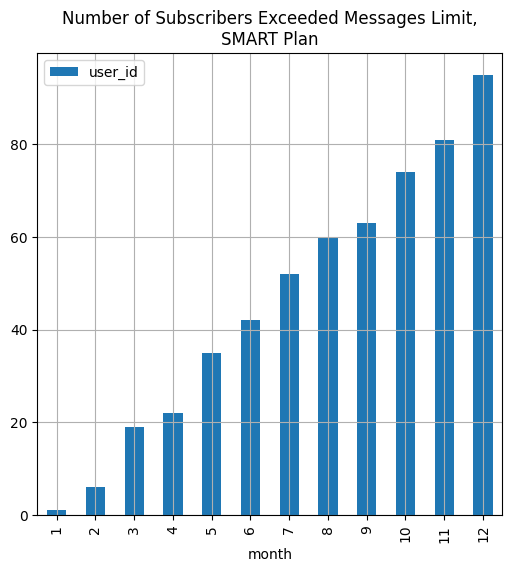

In [109]:
smart_message.query('extra_message > 0').pivot_table(index='month', values='user_id', aggfunc='count').plot(kind='bar', grid=True, figsize=(6, 6))
plt.title('Number of Subscribers Exceeded Messages Limit,\nSMART Plan')

    The number of SMART subscribers exceeding their message limit increased each month from January to December.
    While only one subscriber exceeded the limit in January, the maximum number in December was 95. This represents only 4.3% of the total number of subscribers. This means that in December, the month with the most messages sent, 95.7% of subscribers exceeded the 50-message limit.

### 3.3. What Amount of Internet Traffic Does a User of Each Plan Need Per Month<a class="anchor" id="3-3-bullet"></a>

    Let's plot boxplots for both tariffs to compare the medians and interquartile ranges.

<AxesSubplot:xlabel='tariff', ylabel='internet_gb_used'>

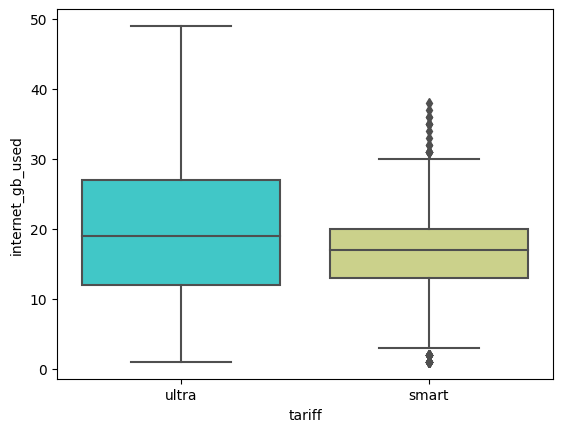

In [110]:
sns.boxplot(x="tariff", y="internet_gb_used", data=common_table, palette='rainbow')

    We see that the median and interquartile range for the ULTRA plan are larger than those for the SMART plan. This means that subscribers with the ULTRA plan, on average, spend more on internet traffic than subscribers with the SMART plan. We also see that the ULTRA plan's dataset is more skewed to the right (the right whisker is longer). This channel attracts those who spend more on internet traffic than the median.

    We'll plot separate range charts for the plans to more accurately identify outliers and remove them in further data analysis.

(0.0, 50.0)

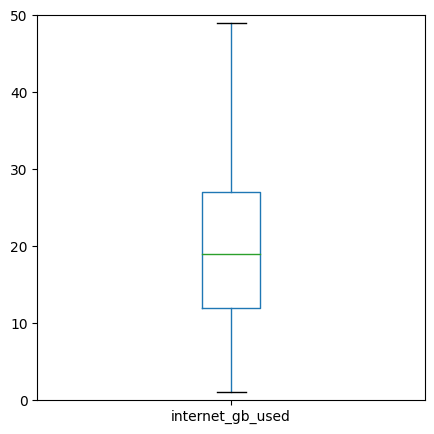

In [111]:
common_table.query('tariff == "ultra"')['internet_gb_used'].plot.box(figsize=(5,5))
plt.ylim(0, 50)

(0.0, 31.0)

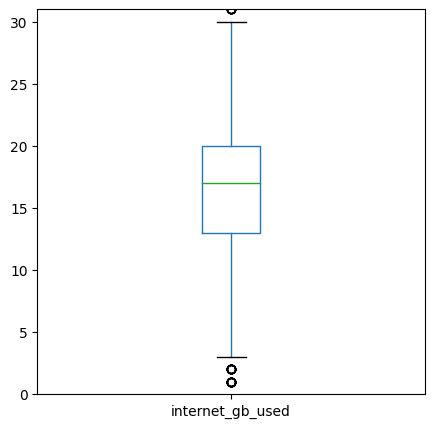

In [112]:
common_table.query('tariff == "smart"')['internet_gb_used'].plot.box(figsize=(5,5))
plt.ylim(0, 31)

In [113]:
smart_internet = common_table[(common_table['tariff'] == 'smart') & (common_table['internet_gb_used'] < 31)]
ultra_internet = common_table[(common_table['tariff'] == 'ultra') & (common_table['internet_gb_used'] < 50)]

In [114]:
mean_ultra_internet = ultra_internet['internet_gb_used'].mean()
mean_smart_internet = smart_internet['internet_gb_used'].mean()
median_ultra_internet = ultra_internet['internet_gb_used'].median()
median_smart_internet = smart_internet['internet_gb_used'].median()
dispersion_ultra_internet = ultra_internet['internet_gb_used'].var()
dispersion_smart_internet = smart_internet['internet_gb_used'].var()
std_ultra_internet = ultra_internet['internet_gb_used'].std()
std_smart_internet = smart_internet['internet_gb_used'].std()
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average monthly internet traffic, Ultra plan {:.0f}'.format(mean_ultra_internet), 'ГБ.')
print('Average monthly internet traffic, Smart plan {:.0f}'.format(mean_smart_internet), 'ГБ.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Median monthly internet traffic, Ultra plan {:.0f}'.format(median_ultra_internet), 'ГБ.')
print('Median monthly internet traffic, Smart plan {:.0f}'.format(median_smart_message), 'ГБ.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Dispersion - Internet traffic volume, Ultra Plan: {:.0f}'.format(dispersion_ultra_internet))
print('Dispersion - Internet traffic volume, Smart Plan: {:.0f}'.format(dispersion_smart_internet))
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Standard deviation - Internet traffic volume, Ultra plan: {:.0f}'.format(std_ultra_internet))
print('Standard deviation - Internet traffic volume, Smart plan: {:.0f}'.format(std_smart_internet))
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average monthly internet traffic, Ultra plan 20 ГБ.
Average monthly internet traffic, Smart plan 16 ГБ.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Median monthly internet traffic, Ultra plan 19 ГБ.
Median monthly internet traffic, Smart plan 33 ГБ.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Dispersion - Internet traffic volume, Ultra Plan: 94
Dispersion - Internet traffic volume, Smart Plan: 31
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Standard deviation - Internet traffic volume, Ultra plan: 10
Standard deviation - Internet traffic volume, Smart plan: 6
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


    Let's simultaneously plot a histogram and a density distribution graph for both plans.

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Internet traffic volume, ULTRA')

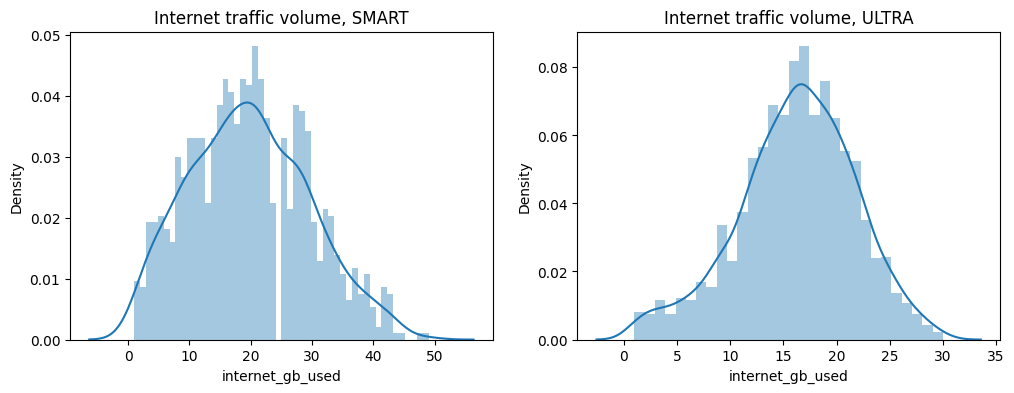

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.distplot(ultra_internet['internet_gb_used'], bins=50, ax=axes[0])
sns.distplot(smart_internet['internet_gb_used'], bins=30, ax=axes[1])
axes[0].set_title('Internet traffic volume, SMART')
axes[1].set_title('Internet traffic volume, ULTRA')

 
***Conclusion:***

    1) Subscribers on the SMART plan require an average of 16 GB of internet traffic.
    The plan includes 15 GB of internet traffic.

    2) Subscribers on the ULTRA plan require an average of 20 GB of internet traffic.
    The plan includes 30 GB of internet traffic, i.e., 1.5 times more than the average subscriber needs.
    Therefore, subscribers overpay for internet traffic and don't use it fully, which benefits the operator.
    As we found above, this is the only category in which subscribers exceed their limit, and it accounts for only 5.8% of total revenue.

    Let's look at how many SMART and ULTRA plan subscribers have exceeded their package limit at least once.

In [116]:
smart_internet.query('extra_internet > 0')['user_id'].count()

1291

In [117]:
ultra_internet.query('extra_internet > 0')['user_id'].count()

134

    1 291 SMART subscribers exceeded the 15GB limit per month at least once, representing 57.9% of all SMART subscribers.

    134 ULTRA subscribers exceeded the 30GB limit per month at least once, representing 13.6% of all ULTRA subscribers.

    Let's look at the behavior of subscribers exceeding their limit by month.

In [118]:
smart_internet.query('extra_internet > 0').pivot_table(index='month', values='user_id', aggfunc='count')

,user_id
month,
1,7
2,14
3,40
4,45
5,78
6,90
7,112
8,145
9,149


In [119]:
ultra_internet.query('extra_internet > 0').pivot_table(index='month', values='user_id', aggfunc='count')

,user_id
month,
2,2
3,5
4,5
5,6
6,9
7,14
8,17
9,14
10,17


Text(0.5, 1.0, 'Subscribers Exceeded the Internet Traffic Limit,\nSMART and ULTRA plans')

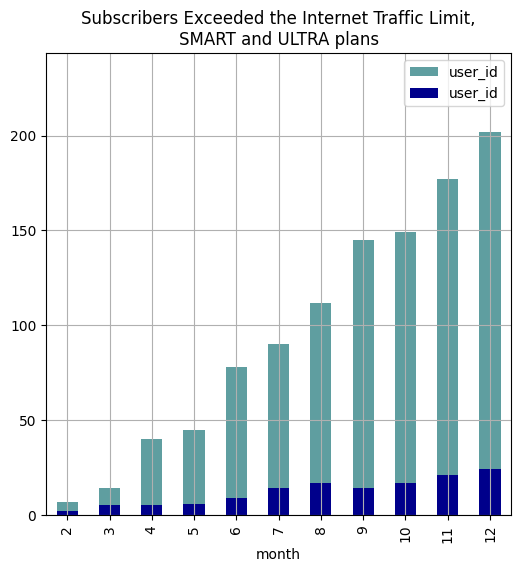

In [120]:
ax = smart_internet.query('extra_internet > 0').pivot_table(index='month', values='user_id', aggfunc='count').plot(kind='bar', grid=True, color = 'cadetblue', figsize=(6, 6))
ultra_internet.query('extra_internet > 0').pivot_table(index='month', values='user_id', aggfunc='count').plot(ax=ax, kind='bar', grid=True, color = 'darkblue', figsize=(6, 6))
plt.title('Subscribers Exceeded the Internet Traffic Limit,\nSMART and ULTRA plans')

    The number of SMART subscribers exceeding their internet traffic limit increased each month from January to December.
    While only 7 subscribers exceeded their limit in January, the maximum number in December was 232. This represents 10.4% of the total number of subscribers. This means that in December, the month with the highest internet traffic consumption, 89.6% of subscribers exceeded their 15GB limit.

    The number of ULTRA subscribers exceeding their internet traffic limit increased each month from January to December.
    While only 2 subscribers exceeded their limit in January, the maximum number in December was 24. This represents 2.4% of the total number of subscribers. This means that in December, the month with the highest internet traffic consumption, 97.6% of subscribers exceeded their 30GB limit.

## Step 4. Hypothesis Testing<a class="anchor" id="4-bullet"></a>

### 4.1. The Average Revenue of Users of the "Ultra" and "Smart" Plans Differs <a class="anchor" id="4-1-bullet"></a>


    
*H0 (null hypothesis)* - the average revenue of users on the ***smart*** plan does not differ from the average revenue of users on the ***ultra*** plan.

*H1 (alternative hypothesis)* - the average revenue of users on the ***smart*** plan differs from the average revenue of users on the ***ultra*** plan.

In [121]:
from scipy import stats as st


    Let's create two separate samples by tariffs in order to later compare average revenues.

In [122]:
pd.set_option('mode.chained_assignment', None)
smart_tariff = common_table[(common_table['tariff'] == 'smart')]
ultra_tariff = common_table[(common_table['tariff'] == 'ultra')]

In [123]:
alpha = 0.05
results = st.ttest_ind(smart_tariff['revenue'], ultra_tariff['revenue'], equal_var = True)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print ('we reject the hypothesis')
else:
    print ('failed to reject the hypothesis')

p-value: 2.9776448000521676e-158
we reject the hypothesis


 
Thus, the average revenue of users of the ***smart*** tariff differs from the average revenue of users of the ***ultra*** tariff.

### 4.2. The Average Revenue of Users in Moscow Differs from That of Users in Other Regions<a class="anchor" id="4-2-bullet"></a>

Since we established above that the average revenue of the two plans differs, it would be incorrect to combine these two groups when analyzing revenue across different regions. This is because the performance of ***ultra*** subscribers in different regions can significantly impact the performance of ***smart*** subscribers.
    Let's test the hypothesis for both plans.

***Smart Plan:***

*H0 (null hypothesis)* - the average revenue of Moscow users does not differ from that of users in other regions on the ***smart*** plan.

*H1 (alternative hypothesis)* - the average revenue of Moscow users differs from that of users in other regions on the ***smart*** plan.

***Ultra Plan:***

*H0 (null hypothesis)* - the average revenue of Moscow users does not differ from that of users in other regions on the ***ultra*** plan.

*H1 (alternative hypothesis)* - the average revenue of users from Moscow differs from the revenue of users from other regions of the ***ultra*** tariff.

In [124]:
def region_groups(row):
    if row['city'] == 'Москва':
        return 'Москва'
    else:
        return 'другой регион'

smart_tariff['region_groups'] = smart_tariff.apply(region_groups, axis=1)
ultra_tariff['region_groups'] = ultra_tariff.apply(region_groups, axis=1)

In [125]:
smart_tariff.head(4)

,user_id,month,call_duration,amount_message,internet_mb_used,age,churn_date,city,first_name,last_name,reg_date,tariff,internet_gb_used,extra_minutes,extra_message,extra_internet,income_calls,income_message,income_internet,total_income,revenue,rub_monthly_fee,region_groups
8,1001,11,430.0,NaN,18452.0,41,NaT,Москва,Иван,Ежов,2018-11-01,smart,19.0,0.0,0.0,4.0,0.0,0.0,800.0,800.0,1350.0,550,Москва
9,1001,12,414.0,NaN,14053.0,41,NaT,Москва,Иван,Ежов,2018-11-01,smart,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,550.0,550,Москва
10,1002,6,117.0,4.0,10871.0,59,NaT,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,550.0,550,другой регион
11,1002,7,214.0,11.0,17601.0,59,NaT,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,18.0,0.0,0.0,3.0,0.0,0.0,600.0,600.0,1150.0,550,другой регион


In [126]:
ultra_tariff.head(4)

,user_id,month,call_duration,amount_message,internet_mb_used,age,churn_date,city,first_name,last_name,reg_date,tariff,internet_gb_used,extra_minutes,extra_message,extra_internet,income_calls,income_message,income_internet,total_income,revenue,rub_monthly_fee,region_groups
0,1000,5,159.0,22.0,2256.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950,другой регион
1,1000,6,172.0,60.0,23257.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950,другой регион
2,1000,7,340.0,75.0,14016.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950,другой регион
3,1000,8,408.0,81.0,14070.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1950.0,1950,другой регион


     Number of subscribers from Moscow and other regions, SMART plan:

In [127]:
smart_tariff['region_groups'].value_counts()

другой регион    1843
Москва            386
Name: region_groups, dtype: int64

    Number of subscribers from Moscow and other regions, ULTRA plan:

In [128]:
ultra_tariff['region_groups'].value_counts()

другой регион    760
Москва           225
Name: region_groups, dtype: int64

    We will divide the SMART TARIFF dataset into two samples depending on the region to compare average revenue

In [129]:
pd.set_option('mode.chained_assignment', None)
smart_tariff_moscow = smart_tariff[(smart_tariff['region_groups'] == 'Москва')]
smart_tariff_region = smart_tariff[(smart_tariff['region_groups'] == 'другой регион')]

In [130]:
from scipy import stats as st
alpha = 0.05
results = st.ttest_ind(smart_tariff_moscow['revenue'], smart_tariff_region['revenue'], equal_var = False)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print ('we reject the hypothesis')
else:
    print ('failed to reject the hypothesis')

p-value: 0.1642380351651886
failed to reject the hypothesis


    Thus, the average revenue of Moscow users is no different from that of users in other regions on the SMART plan.

In [131]:
mean_income_smart_moscow = smart_tariff_moscow['revenue'].mean()
mean_income_smart_region = smart_tariff_region['revenue'].mean()
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average monthly revenue for Moscow users, Smart plan {:.0f}'.format(mean_income_smart_moscow), 'руб.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average monthly revenue for users from other regions, Smart plan {:.0f}'.format(mean_income_smart_region), 'руб.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average monthly revenue for Moscow users, Smart plan 1245 руб.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average monthly revenue for users from other regions, Smart plan 1305 руб.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


    We will split the Ultra Plan dataset into two samples depending on the region to compare average revenue

In [132]:
pd.set_option('mode.chained_assignment', None)
ultra_tariff_moscow = ultra_tariff[(ultra_tariff['region_groups'] == 'Москва')]
ultra_tariff_region = ultra_tariff[(ultra_tariff['region_groups'] == 'другой регион')]

In [133]:
from scipy import stats as st
alpha = 0.05
results = st.ttest_ind(ultra_tariff_region['revenue'], ultra_tariff_moscow['revenue'], equal_var = False)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print ('we reject the hypothesis')
else:
    print ('failed to reject the hypothesis')

p-value: 0.8400933420531973
failed to reject the hypothesis


    Thus, the average revenue of Moscow users is no different from that of users in other regions using the Ultra plan.

In [134]:
mean_income_ultra_moscow = ultra_tariff_moscow['revenue'].mean()
mean_income_ultra_region = ultra_tariff_region['revenue'].mean()
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average monthly revenue for Moscow users, Ultra plan {:.0f}'.format(mean_income_ultra_moscow), 'руб.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('Average monthly revenue for users from other regions, Ultra plan {:.0f}'.format(mean_income_ultra_region), 'руб.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average monthly revenue for Moscow users, Ultra plan 2075 руб.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Average monthly revenue for users from other regions, Ultra plan 2070 руб.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


    Average subscriber revenue in Moscow and the regions is similar for the ULTRA plan, as most subscribers only pay the monthly fee, which is the same for everyone. Only 5.8% of this amount goes toward additional charges for internet traffic. We previously found that only 13.6% of all subscribers exceeded their data limit. Let's look at where these subscribers come from.

In [135]:
ultra_tariff.query('extra_internet > 0').pivot_table(index='region_groups', values=('income_internet'), aggfunc=('count', 'sum'))

,count,sum
region_groups,,
Москва,37,28200.0
другой регион,97,91050.0


    Subscribers who exceeded their data allowances were found in both Moscow and the regions.

    In the regions, 97 subscribers exceeded their data allowances, and they paid a total of 91 050 rubles (4.4% of total revenue).
    In Moscow, 37 subscribers exceeded their data allowances, and they paid a total of 28 200 rubles (1.4% of total revenue).

    For the overall dataset, the difference may not be significant enough to be statistically significant.

## Step 5. General Conclusion<a class="anchor" id="5-bullet"></a>

The behavior of customers on two tariff plans, ***smart*** and ***ultra***, was analyzed.
The ***ultra*** tariff generates more revenue. The advertising budget should be adjusted based on this information.

* Average revenue per user of the smart tariff (in this sample) is 1 294.64 rubles.
* Average revenue per user of the ultra tariff (in this sample) is 2 071.07 rubles.

Next, the hypothesis was tested that, in the general population, the average revenue of ***smart*** users differs from the average revenue of ***ultra*** users. There is no reason to reject this hypothesis.

***SMART*** Tariff

1. The number of subscribers in the sample is 2 229, which is 69.35% of the total sample.

2. Subscribers exceed their limits in all categories: calls, messages, and data traffic. This means that subscribers pay an additional fee for each category in addition to their monthly subscription fee. The majority of revenue comes from additional fees for "extra" services – 57.5% of total revenue for the plan.
The monthly subscription fee is 42.5% of the plan's total revenue.

Revenue for the ***smart*** plan is as follows:
* Internet surcharge – tariff = 46.5%
* monthly subscription fee – 42.5%
* call minute surcharge – 9.6%
* message surcharge – 1.4%

3. Subscribers use an average of 417 minutes of call time per month.
The plan includes 500 minutes of call time.
The number of subscribers exceeding their call minute limit increases each month from January to December. While only one subscriber exceeded the limit in January, the maximum number in December was 138. This represents only 6.2% of the total number of subscribers. This means that in December, the month with the most call minutes, ***93.8%*** of subscribers exceeded their 500-minute limit.

4. Subscribers send an average of 38 messages per month.
The plan includes 50 messages per month.
The number of subscribers exceeding their message limit increases each month from January to December. While only one subscriber exceeded the limit in January, the maximum number in December was 95 subscribers. This represents only 4.3% of the total number of subscribers. This means that in December, the month with the most messages sent, ***95.7%*** of subscribers exceeded their 50-message limit.

5. Subscribers require an average of 16 GB of internet traffic.
The plan includes 15 GB of internet traffic, meaning On average, subscribers are short 1GB per month.
The number of subscribers exceeding their internet traffic limit increased each month from January to December. While only 7 subscribers exceeded their limit in January, the maximum number in December was 232. This represents 10.4% of the total number of subscribers. Therefore, in December, the month with the highest internet traffic consumption, ***89.6%*** of subscribers exceeded their 15GB limit.

6. We tested the hypothesis that, in the general population, the average revenue of Moscow users does not differ from that of users in other regions on the ***smart*** plan. The data confirmed this hypothesis; there is no reason to reject it.

* Average monthly revenue of Moscow users (in this sample) is 1,245 rubles.
* Average monthly revenue for users in other regions (in this sample) is 1,305 rubles.

***ULTRA Plan***

1. The sample includes 985 subscribers, representing 30.65% of the total sample.

2. Subscribers to this plan never exceeded their call or text limit over the year. Subscribers only exceed their data traffic limit.

The majority of revenue comes from subscription fees – ***94.2%***. Data traffic surcharges account for only 5.8%.

3. Subscribers use an average of 545 minutes of talk time per month.
The plan includes 3,000 minutes of talk time, almost five times more than the average subscriber needs.
Therefore, subscribers overpay for call minutes and don't use them, which benefits the operator. As we found above, not a single subscriber exceeded their limit in this category.

4. Subscribers send an average of 59 messages per month.
The plan includes 1,000 messages, i.e., almost 17 times more than the average subscriber needs.
Therefore, subscribers are overpaying for messages and not using them, which benefits the operator. As we found above, not a single subscriber exceeded their limit in this category.

5. Subscribers require an average of 20 GB of internet traffic.
The plan includes 30 GB of internet traffic, i.e., 1.5 times more than the average subscriber needs.
Therefore, subscribers are overpaying for internet traffic and not using it fully, which benefits the operator.
The number of ***ultra*** subscribers exceeding their internet traffic limit has been growing monthly from January to December. While only two subscribers exceeded their limit in January, the maximum number in December was 24. This represents 2.4% of the total number of subscribers. This means that in December, the month with the highest internet traffic consumption, ***97.6%*** of subscribers exceeded their 30GB limit.

6. We have no reason to reject the hypothesis that the average revenue of Moscow users is no different from that of users in other regions on the Ultra plan. Subscribers generally pay only the monthly fee, which is the same for everyone. Only 5.8% of revenue comes from additional charges for internet traffic. We found that only 13.6% of all subscribers exceeded their data limit. This group includes both Moscow and regional subscribers.